In [19]:
import holoocean
import numpy as np
from pynput import keyboard
import matplotlib.pyplot as plt
import csv


In [20]:
pressed_keys = list()
force = 10

def on_press(key):
    global pressed_keys
    if hasattr(key, 'char'):
        pressed_keys.append(key.char)
        pressed_keys = list(set(pressed_keys))

def on_release(key):
    global pressed_keys
    if hasattr(key, 'char'):
        pressed_keys.remove(key.char)

listener = keyboard.Listener(
    on_press=on_press,
    on_release=on_release)
listener.start()

def parse_keys(keys, val):
    command = np.zeros(8)
    if 'i' in keys:
        command[0:4] += val
    if 'k' in keys:
        command[0:4] -= val
    if 'j' in keys:
        command[[4,7]] += .25 * val
        command[[5,6]] -= .25 * val
    if 'l' in keys:
        command[[4,7]] -= .25 * val
        command[[5,6]] += .25 * val

    if 'w' in keys:
        command[4:8] += val
    if 's' in keys:
        command[4:8] -= val
    if 'a' in keys:
        command[[4,6]] += val
        command[[5,7]] -= val
    if 'd' in keys:
        command[[4,6]] -= val
        command[[5,7]] += val

    return command

In [3]:
def vortex_field(location):
    x, y, z = location
    if z > 0:
        return [0, 0, 0]
    strength = 5.0
    r_squared = x**2 + y**2 + 1e-5  # avoid divide by zero
    dx = -y / r_squared * strength
    dy = x / r_squared * strength
    dz = 0.2 * np.cos(0.1 * r_squared)
    return [3*dx, 3*dy, 3*dz]

In [10]:
vehicles = ['auv']
map_dimensions = [50, 50, 20 ]

In [ ]:
clock = 0
    while True:
        clock += 1
        if clock == 2000:
            env.draw_debug_vector_field(vortex_field, location=[0, 0, 0], vector_field_dimensions=map_dimensions, arrow_thickness=7, arrow_size=.25, spacing=3)
        tick_info = env.tick()
        command = parse_keys(pressed_keys, force)
        env.act("auv0", command)

        # Apply currents
        for vehicle in vehicles:
            location = tick_info[vehicle]['LocationSensor']
            current_velocity = vortex_field(location)
            env.set_ocean_currents(vehicle, current_velocity)

KeyboardInterrupt: 

In [17]:
with holoocean.make("blue_rov") as env:
    for k in range(100):
        state = env.tick()

        imu  = state["auv"]["IMUSensor"]    # (2x3 or 4x3 array)
        pose = state["auv"]["PoseSensor"]   # 4x4 homogeneous matrix

        # break out into pieces:
        accel_body = imu[0, :]
        gyro_body  = imu[1, :]
        accel_bias = imu[2, :]   # bias estimate
        gyro_bias  = imu[3, :]

        T_ws = pose        # 4x4
        R_ws = T_ws[0:3, 0:3]   # rotation
        p_w  = T_ws[0:3, 3]     # position in world

        print("Accel (body):", accel_body)
        print("Gyro  (body):", gyro_body)
        print("Accel bias:", accel_bias)
        print("Gyro bias :", gyro_bias)
        print("R_ws:", R_ws)
        print("p_w :", p_w)
        break


DVLSensor rate 20 is not a factor of ticks_per_sec 30, rounding to 30
Accel (body): [-1.26504805e-02 -5.06661646e-03  9.80549431e+00]
Gyro  (body): [ 0.00410084 -0.01769966  0.01762898]
Accel bias: [-0.01325582 -0.00849347  0.00520998]
Gyro bias : [ 0.00562131 -0.01514747  0.01608006]
R_ws: [[-0.7071067  0.7071068  0.       ]
 [-0.7071068 -0.7071067 -0.       ]
 [ 0.        -0.         1.       ]]
p_w : [ 31.5  91.5 -37. ]


### checking out depth sensor

In [2]:
import holoocean
import numpy as np


with holoocean.make("blue_rov") as env:
    for k in range(100):
        state = env.tick()

        depth  = state["auv"]["DepthSensor"]    # (2x3 or 4x3 array)

        print("Depth:", depth)

        break

DVLSensor rate 20 is not a factor of ticks_per_sec 30, rounding to 30
Depth: [-15.024001]


### 2.2. Python script to compare “clean” vs “noisy”

In [1]:
import holoocean
import numpy as np
import matplotlib.pyplot as plt

TICKS_PER_SEC = 30
N_STEPS = 1000

accel_log = []
gyro_log  = []
accel_bias_log = []
gyro_bias_log  = []
times = []

env.set_render_quality(0)


with holoocean.make("blue_rov") as env:
    dt = 1.0 / TICKS_PER_SEC

    for k in range(N_STEPS):
        state = env.tick()
        imu = state["auv"]["IMUSensor"]  # shape (4,3) now

        accel_body = imu[0, :]
        gyro_body  = imu[1, :]
        accel_bias = imu[2, :]
        gyro_bias  = imu[3, :]

        t = k * dt
        times.append(t)
        accel_log.append(accel_body.copy())
        gyro_log.append(gyro_body.copy())
        accel_bias_log.append(accel_bias.copy())
        gyro_bias_log.append(gyro_bias.copy())

times = np.array(times)
accel_log = np.array(accel_log)         # shape (N,3)
gyro_log = np.array(gyro_log)
accel_bias_log = np.array(accel_bias_log)
gyro_bias_log = np.array(gyro_bias_log)

# Example: plot accel_x and its bias over time
plt.figure()
plt.plot(times, accel_log[:, 0], label="accel_x noisy")
plt.plot(times, accel_bias_log[:, 0], label="accel_x bias")
plt.xlabel("time [s]")
plt.ylabel("m/s^2")
plt.legend()
plt.title("IMU accel_x: noise + bias")
plt.show()


NameError: name 'env' is not defined

### 3. Using PoseSensor in the EKF

In [6]:
import numpy as np

class EKF:
    def __init__(self, dt):
        self.dt = dt
        self.x = np.zeros(6)
        self.P = np.eye(6) * 1.0

        self.Q = np.diag([0.01, 0.01, 0.01,
                          0.1,  0.1,  0.1])

    def predict(self, a_world):
        dt = self.dt

        F = np.eye(6)
        F[0, 3] = dt
        F[1, 4] = dt
        F[2, 5] = dt

        B = np.zeros((6, 3))
        B[3, 0] = dt
        B[4, 1] = dt
        B[5, 2] = dt

        a_world = np.asarray(a_world).reshape(3,)

        self.x = F @ self.x + B @ a_world
        self.P = F @ self.P @ F.T + self.Q


### 3.4. Full IMU-only loop using PoseSensor

DVLSensor rate 20 is not a factor of ticks_per_sec 30, rounding to 30


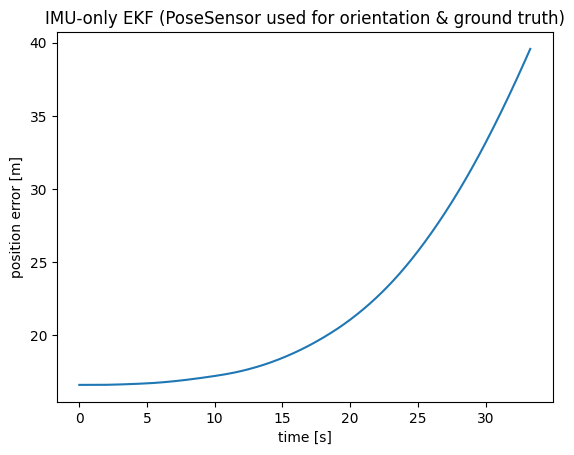

In [12]:
import holoocean
import numpy as np
import matplotlib.pyplot as plt

TICKS_PER_SEC = 30
DT = 1.0 / TICKS_PER_SEC
N_STEPS = 1000

ekf = EKF(dt=DT)

true_positions = []
est_positions  = []
times          = []

with holoocean.make("blue_rov") as env:
    env.set_render_quality(0)   # OPTIONAL: Set render quality to low for faster performance

    clock = 0

    for k in range(N_STEPS):
        state = env.tick()
        # 1) Get IMU
        imu = state["auv"]["IMUSensor"]
        accel_body = imu[0, :]

        # 2) Pose → R & p
        pose = state["auv"]["PoseSensor"]   # 4x4
        T_ws = pose
        R_ws = T_ws[0:3, 0:3]
        p_w  = T_ws[0:3, 3]

        # 3) Rotate accel to world, remove gravity
        a_world_raw = R_ws @ accel_body

        # Choose g once from a static test; adjust sign as needed
        g = np.array([0.0, 0.0, 9.81])
        a_world = a_world_raw - g

        # 4) EKF prediction
        ekf.predict(a_world)

        # 5) Log for evaluation
        t = k * DT
        times.append(t)

        true_positions.append(p_w.copy())
        est_positions.append(ekf.x[0:3].copy())




times = np.array(times)
true_positions = np.array(true_positions)
est_positions  = np.array(est_positions)

pos_err = np.linalg.norm(est_positions - true_positions, axis=1)

plt.figure()
plt.plot(times, pos_err)
plt.xlabel("time [s]")
plt.ylabel("position error [m]")
plt.title("IMU-only EKF (PoseSensor used for orientation & ground truth)")
plt.show()


### 2.1. Static test + Dynamic (vehicle resting)

DVLSensor rate 20 is not a factor of ticks_per_sec 30, rounding to 30


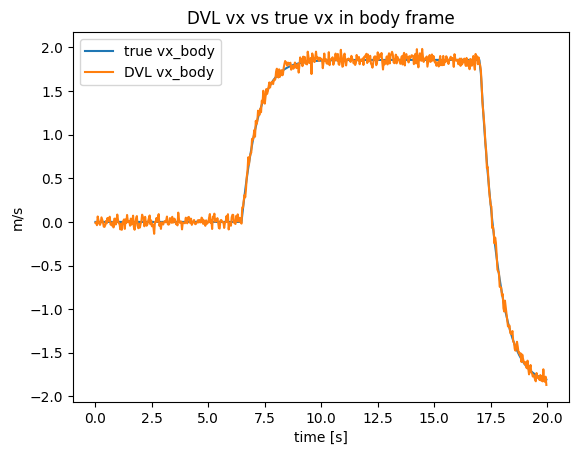

In [25]:
import holoocean
import numpy as np
import matplotlib.pyplot as plt

TICKS_PER_SEC = 30
DT = 1.0 / TICKS_PER_SEC
N_STEPS = 600   # 20 s if 30 Hz

v_body_log  = []
v_true_log  = []
times       = []

with holoocean.make("blue_rov") as env:
    prev_p = None

    for k in range(600):
        state = env.tick()
        # --- Pose (for ground-truth position) ---
        pose = state["auv"]["PoseSensor"]    # 4x4
        T_ws = pose
        p_w  = T_ws[0:3, 3]


        # true velocity in world (finite diff)
        if prev_p is None:
            v_true_world = np.zeros(3)
        else:
            v_true_world = (p_w - prev_p) / DT
        prev_p = p_w.copy()


        # --- DVL velocities (body frame) ---
        dvl = state["auv"]["DVLSensor"]
        v_body = dvl[0:3]
        # rotate true velocity into body frame for comparison
        R_ws = T_ws[0:3, 0:3]
        R_sw = R_ws.T                  # world -> sensor/body
        v_true_body = R_sw @ v_true_world

        v_body_log.append(v_body.copy())
        v_true_log.append(v_true_body.copy())
        times.append(k * DT)


        command = parse_keys(pressed_keys, force)
        env.act("auv", command)

times      = np.array(times)
v_body_log = np.array(v_body_log)
v_true_log = np.array(v_true_log)


plt.figure()
plt.plot(times, v_true_log[:, 0], label="true vx_body")
plt.plot(times, v_body_log[:, 0], label="DVL vx_body")
plt.xlabel("time [s]")
plt.ylabel("m/s")
plt.legend()
plt.title("DVL vx vs true vx in body frame")
plt.show()


In [29]:
import numpy as np

class EKF:
    def __init__(self, dt):
        self.dt = dt
        self.x = np.zeros(6)
        self.P = np.eye(6) * 1.0

        self.Q = np.diag([0.01, 0.01, 0.01,
                          0.1,  0.1,  0.1])

    def predict(self, a_world):
        dt = self.dt

        F = np.eye(6)
        F[0, 3] = dt
        F[1, 4] = dt
        F[2, 5] = dt

        B = np.zeros((6, 3))
        B[3, 0] = dt
        B[4, 1] = dt
        B[5, 2] = dt

        a_world = np.asarray(a_world).reshape(3,)

        self.x = F @ self.x + B @ a_world
        self.P = F @ self.P @ F.T + self.Q

    def update_linear(self, z, H, R):
        z = np.asarray(z).reshape(-1, 1)
        H = np.asarray(H)
        R = np.asarray(R)

        x = self.x.reshape(-1, 1)

        y = z - H @ x                # innovation
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = (x + K @ y).flatten()
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ H) @ self.P


DVLSensor rate 20 is not a factor of ticks_per_sec 30, rounding to 30


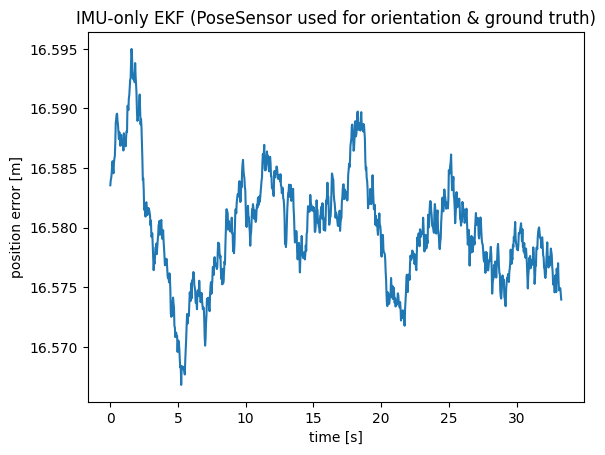

Unhandled exception in listener callback
Traceback (most recent call last):
  File "/home/hamza/.local/lib/python3.10/site-packages/pynput/_util/__init__.py", line 230, in inner
    return f(self, *args, **kwargs)
  File "/home/hamza/.local/lib/python3.10/site-packages/pynput/_util/xorg.py", line 472, in _handler
    self._handle_message(self._display_stop, event, injected)
  File "/home/hamza/.local/lib/python3.10/site-packages/pynput/keyboard/_xorg.py", line 581, in _handle_message
    self.on_release(key, injected)
  File "/home/hamza/.local/lib/python3.10/site-packages/pynput/_util/__init__.py", line 146, in inner
    if f(*args) is False:
  File "/home/hamza/.local/lib/python3.10/site-packages/pynput/_util/__init__.py", line 291, in <lambda>
    return lambda *a: f(*a[:actual])
  File "/tmp/ipykernel_159154/2556387761.py", line 13, in on_release
    pressed_keys.remove(key.char)
ValueError: list.remove(x): x not in list


In [ ]:
import holoocean
import numpy as np
import matplotlib.pyplot as plt

TICKS_PER_SEC = 30
DT = 1.0 / TICKS_PER_SEC
N_STEPS = 1000

ekf = EKF(dt=DT)

true_positions = []
est_positions  = []
times          = []

with holoocean.make("blue_rov") as env:
    env.set_render_quality(0)   # OPTIONAL: Set render quality to low for faster performance

    clock = 0

    for k in range(N_STEPS):
        state = env.tick()
        # 1) Get IMU
        imu = state["auv"]["IMUSensor"]
        accel_body = imu[0, :]

        # 2) Pose → R & p
        pose = state["auv"]["PoseSensor"]   # 4x4
        T_ws = pose
        R_ws = T_ws[0:3, 0:3]
        p_w  = T_ws[0:3, 3]



        # 3) Rotate accel to world, remove gravity
        a_world_raw = R_ws @ accel_body

        # Choose g once from a static test; adjust sign as needed
        g = np.array([0.0, 0.0, 9.81])
        a_world = a_world_raw - g

        # 4) EKF prediction
        ekf.predict(a_world)

        dvl = state["auv"]["DVLSensor"]
        v_body = dvl[0:3]

        # convert to world frame
        pose = state["auv"]["PoseSensor"]
        R_ws = pose[0:3, 0:3]
        v_world_meas = R_ws @ v_body

        # measurement matrices
        H_dvl = np.array([
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1],
        ])
        sigma_v = 0.05  # tune
        R_dvl = np.diag([sigma_v**2, sigma_v**2, sigma_v**2])

        # EKF update with DVL
        if k % (TICKS_PER_SEC // 20) == 0:  # 20 Hz
            ekf.update_linear(v_world_meas, H_dvl, R_dvl)

        # 5) Log for evaluation
        t = k * DT
        times.append(t)

        true_positions.append(p_w.copy())
        est_positions.append(ekf.x[0:3].copy())




times = np.array(times)
true_positions = np.array(true_positions)
est_positions  = np.array(est_positions)

pos_err = np.linalg.norm(est_positions - true_positions, axis=1)

plt.figure()
plt.plot(times, pos_err)
plt.xlabel("time [s]")
plt.ylabel("position error [m]")
plt.title("IMU-only EKF (PoseSensor used for orientation & ground truth)")
plt.show()


In [ ]:
import holoocean
import numpy as np
import matplotlib.pyplot as plt

TICKS_PER_SEC = 30
DT = 1.0 / TICKS_PER_SEC
N_STEPS = 600   # 20 s if 30 Hz

v_body_log  = []
v_true_log  = []
times       = []

with holoocean.make("blue_rov") as env:
    prev_p = None

    for k in range(600):
        state = env.tick()
        # --- Pose (for ground-truth position) ---
        pose = state["auv"]["PoseSensor"]    # 4x4
        T_ws = pose
        p_w  = T_ws[0:3, 3]


        # true velocity in world (finite diff)
        if prev_p is None:
            v_true_world = np.zeros(3)
        else:
            v_true_world = (p_w - prev_p) / DT
        prev_p = p_w.copy()


        # --- DVL velocities (body frame) ---
        dvl = state["auv"]["DVLSensor"]
        v_body = dvl[0:3]
        # rotate true velocity into body frame for comparison
        R_ws = T_ws[0:3, 0:3]
        R_sw = R_ws.T                  # world -> sensor/body
        v_true_body = R_sw @ v_true_world

        v_body_log.append(v_body.copy())
        v_true_log.append(v_true_body.copy())
        times.append(k * DT)


        command = parse_keys(pressed_keys, force)
        env.act("auv", command)

times      = np.array(times)
v_body_log = np.array(v_body_log)
v_true_log = np.array(v_true_log)


plt.figure()
plt.plot(times, v_true_log[:, 0], label="true vx_body")
plt.plot(times, v_body_log[:, 0], label="DVL vx_body")
plt.xlabel("time [s]")
plt.ylabel("m/s")
plt.legend()
plt.title("DVL vx vs true vx in body frame")
plt.show()
